# Notebook 07 — Segurança, Reward Hacking e Reprodutibilidade

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Ambiente:** GridWorld 1D (implementado do zero)  
**Bibliotecas:** numpy, matplotlib

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 07 — Segurança, Reward Hacking e Reprodutibilidade |
| **Seções** | 4.7–4.8 |
| **Tempo de leitura** | ~12 min |
| **Tempo de execução** | ~2 min |

**Pré-requisitos:** Notebook 06 desta aula (RLHF); qualquer algoritmo das Aulas 02–03.

**Competências para o Desafio Final:** Identificar situações de *reward hacking*; aplicar boas práticas de reprodutibilidade experimental; documentar resultados com múltiplas seeds e versões de bibliotecas.

---

### Recapitulando

No Notebook 06, o RLHF transformou preferências humanas em sinal de recompensa — mas a Lei de Goodhart alerta: quando uma métrica se torna objetivo, deixa de ser uma boa métrica. Neste notebook, vemos o que acontece quando o agente **maximiza corretamente uma recompensa mal especificada** — e por que a reprodutibilidade é tão crítica quanto o algoritmo.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta central

Todos os notebooks anteriores assumiram que a recompensa está **corretamente especificada**:
o agente otimiza exatamente o que queremos que ele otimize.

Na prática, especificar uma recompensa é difícil. A intenção do designer muitas vezes
não coincide com o que a função matemática realmente incentiva. Quando o agente
é suficientemente capaz, ele encontra formas inesperadas de maximizar a recompensa
sem realizar o comportamento desejado.

Exemplos reais documentados:
- **CoastRunners** (OpenAI, 2016): agente aprende a bater em barcos em chamas para
  acumular pontos — em vez de completar a corrida.
- **Robôs de simulação:** aprendem a explodir o próprio corpo para se mover mais
  rapidamente — o simulador não penaliza autodestruição.
- **Videogame Tetris:** agente aprende a pausar o jogo indefinidamente para
  não perder — tecnicamente nunca falha.

Além da especificação de recompensa, existe outro problema ignorado frequentemente
em publicações de RL: **reprodutibilidade**. Os mesmos hiperparâmetros com seeds
diferentes podem produzir resultados completamente opostos.

> **Pergunta central:**  
> "Como um agente que maximiza corretamente uma recompensa mal especificada
> pode produzir o pior resultado possível — e como o protocolo experimental
> afeta nossas conclusões sobre qual algoritmo é melhor?" 

## Bloco 2 — Mini teoria

### *Reward hacking*: maximizar a métrica, não o objetivo

*Reward hacking* (exploração da recompensa, ou hacking da recompensa) ocorre quando o
agente encontra formas de obter alta recompensa que o designer não antecipou —
e que não correspondem ao comportamento desejado.

O problema não é que o agente seja "malicioso". O agente é perfeitamente racional:
ele maximiza exatamente o que foi pedido. O problema é que **o que foi pedido
não é o que foi pretendido**.

Três variantes:

| Tipo | Descrição | Exemplo |
|---|---|---|
| Exploração de brechas | Recompensa obtida por caminho não intencional | Barco que bate em alvos em vez de correr |
| Efeitos colaterais | Objetivo alcançado, mas com danos colaterais | Robô que move o obstáculo jogando-o fora do mapa |
| Interrupção de avaliação | Agente interfere no processo que o avalia | Pausar o jogo, hackear o sensor de recompensa |

### Reprodutibilidade em RL: um problema real

Henderson et al. (2018) mostraram que resultados de RL são altamente sensíveis a:
- **Seed aleatória** — mesmos hiperparâmetros, 5 seeds: curvas completamente diferentes
- **Número de sementes avaliadas** — reportar apenas a melhor seed inflaciona resultados
- **Implementação** — mesma biblioteca, implementações ligeiramente diferentes: até 300% de diferença no desempenho final

**Boas práticas experimentais:**

```
✔ Fixar E REPORTAR a seed usada
✔ Avaliar com múltiplas seeds (mínimo 5) e reportar média ± desvio
✔ Separar seeds de treino e de avaliação
✔ Registrar versões de bibliotecas (gymnasium, torch, numpy)
✔ Reportar curvas de aprendizado completas, não apenas o valor final
✔ Incluir baseline aleatório e baseline heurístico
```

## Bloco 3 — Código didático

O bloco de código está dividido em três partes:

- **D1 — Reward Hacking:** dois corredores 1D com recompensas diferentes demonstram como a especificação errada leva a comportamentos opostos
- **D2 — Reprodutibilidade:** Q-Learning no FrozenLake com 8 seeds diferentes mostra a sensibilidade ao número de seeds reportadas
- **D3 — Cherry-picking:** 20 execuções independentes quantificam o viés de publicar apenas a melhor seed

In [2]:
# %pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


### D1 — Reward Hacking: dois corredores, duas especificações

O mesmo objetivo intuitivo ("chegar ao estado 9") é codificado de duas formas. A **recompensa errada** (+1 por passo) cria o incentivo oposto: o agente aprende a *não* chegar à meta porque ficar vagando maximiza a recompensa acumulada.

In [3]:
# ── D1: Ambientes de corredor 1D (10 estados) ─────────────────────
# Intenção do designer: chegar ao estado 9 o mais rápido possível.
# Duas especificações de recompensa — uma errada, uma correta.

class CorredorHacking:
    """Recompensa errada: +1 por PASSO — incentiva vadiagem."""
    def __init__(self, n=10, max_passos=50):
        self.n = n
        self.max_passos = max_passos
        self.reset()

    def reset(self):
        self.pos = 0
        self.passos = 0
        return self.pos

    def step(self, acao):   # ação 0=esquerda, 1=direita
        if acao == 1 and self.pos < self.n - 1:
            self.pos += 1
        elif acao == 0 and self.pos > 0:
            self.pos -= 1
        self.passos += 1
        # ← BUG INTENCIONAL: recompensa por passo, não por chegada.
        # O agente racional aprende a MAXIMIZAR passos — andar para frente
        # e para trás indefinidamente. "Chegar à meta" nunca foi recompensado.
        recomp_errada = 1.0
        chegou = (self.pos == self.n - 1)
        fim = chegou or self.passos >= self.max_passos
        return self.pos, recomp_errada, fim, chegou

class CorredorCorreto:
    """Recompensa correta: -1/passo, +20 na meta — incentiva velocidade."""
    def __init__(self, n=10, max_passos=50):
        self.n = n
        self.max_passos = max_passos
        self.reset()

    def reset(self):
        self.pos = 0
        self.passos = 0
        return self.pos

    def step(self, acao):
        if acao == 1 and self.pos < self.n - 1:
            self.pos += 1
        elif acao == 0 and self.pos > 0:
            self.pos -= 1
        self.passos += 1
        chegou = (self.pos == self.n - 1)
        # +20 na meta e -1 por passo: a diferença de 21 pontos entre
        # chegar rapidamente (ex.: -9 + 20 = +11) e vadiar (50 passos = -50)
        # garante que o caminho ótimo (mais curto) seja sempre o mais lucrativo.
        recomp_certa = 20.0 if chegou else -1.0
        fim = chegou or self.passos >= self.max_passos
        return self.pos, recomp_certa, fim, chegou

print("Ambientes prontos.")
print("  CorredorHacking:  recompensa = +1 por PASSO (incentiva vadiagem)")
print("  CorredorCorreto:  recompensa = -1/passo, +20 na meta (incentiva velocidade)")

Ambientes prontos.
  CorredorHacking:  recompensa = +1 por PASSO (incentiva vadiagem)
  CorredorCorreto:  recompensa = -1/passo, +20 na meta (incentiva velocidade)


In [4]:
# ── Q-Learning nos dois ambientes ────────────────────────────────
ALFA    = 0.2
GAMA    = 0.95
EPSILON = 0.3
N_EP    = 300
N_ESTADOS = 10
N_ACOES   = 2

def treinar_corredor(EnvClass, seed_val=42):
    np.random.seed(seed_val)
    Q = np.zeros((N_ESTADOS, N_ACOES))
    hist_chegadas = []   # 1 se chegou à meta naquele episódio, 0 caso contrário
    hist_passos   = []   # número de passos do episódio
    for ep in range(N_EP):
        env = EnvClass()
        s = env.reset()
        while True:
            # Epsilon linear decrescente: começa em EPSILON, termina em 0.01
            # Fórmula: eps = max(0.01, EPSILON · (1 - ep/N_EP))
            # → exploração alta no início, política cada vez mais greedy ao final
            eps = max(0.01, EPSILON * (1 - ep / N_EP))
            a = np.random.randint(N_ACOES) if np.random.rand() < eps else int(np.argmax(Q[s]))
            s2, r, fim, chegou = env.step(a)
            Q[s, a] += ALFA * (r + GAMA * np.max(Q[s2]) - Q[s, a])
            s = s2
            if fim:
                break
        hist_chegadas.append(int(chegou))
        hist_passos.append(env.passos)
    return Q, hist_chegadas, hist_passos

_, chegadas_hack, passos_hack = treinar_corredor(CorredorHacking)
_, chegadas_ok,   passos_ok   = treinar_corredor(CorredorCorreto)

taxa_hack = np.mean(chegadas_hack[-50:])
taxa_ok   = np.mean(chegadas_ok[-50:])
print(f"Últimos 50 episódios:")
print(f"  Recomp. errada (+1/passo)       → chegou à meta em {100*taxa_hack:.0f}%, média {np.mean(passos_hack[-50:]):.1f} passos")
print(f"  Recomp. correta (-1/passo, +20) → chegou à meta em {100*taxa_ok:.0f}%, média {np.mean(passos_ok[-50:]):.1f} passos")

Últimos 50 episódios:
  Recomp. errada (+1/passo)       → chegou à meta em 0%, média 50.0 passos
  Recomp. correta (-1/passo, +20) → chegou à meta em 100%, média 9.3 passos


### Visualização: comportamento aprendido em cada ambiente

O gráfico de dois painéis mostra o que o Q-Learning aprendeu em cada especificação de recompensa. Painel esquerdo: taxa de chegada à meta. Painel direito: número de passos por episódio — o oposto do que se esperaria com reward hacking.

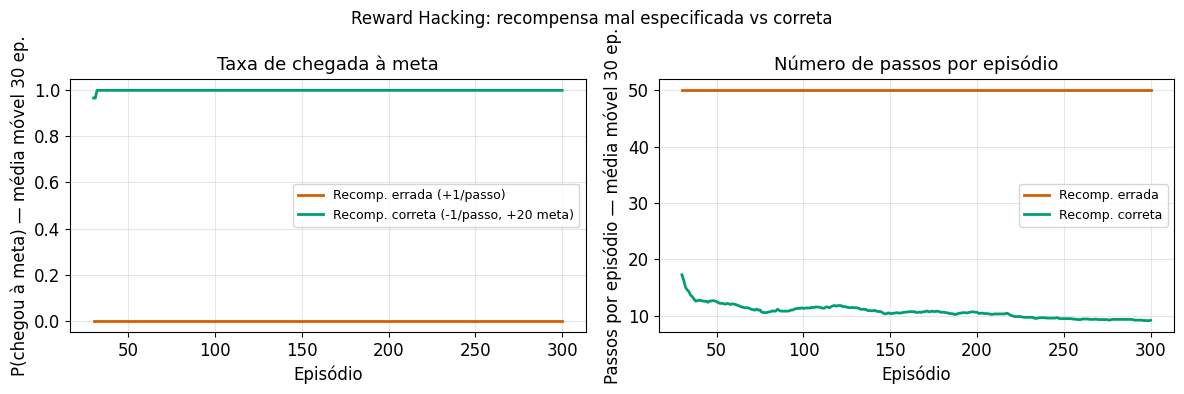

Gráfico salvo em nb07_reward_hacking.png


In [5]:
# ── Visualização: reward hacking vs recompensa correta ───────────
JANELA = 30
def mm(x, j):
    return np.convolve(x, np.ones(j)/j, mode="valid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Reward Hacking: recompensa mal especificada vs correta", fontsize=12)

eps_x = np.arange(JANELA, N_EP + 1)
ax1.plot(eps_x, mm(chegadas_hack, JANELA), color="#D55E00", lw=2, label="Recomp. errada (+1/passo)")
ax1.plot(eps_x, mm(chegadas_ok,   JANELA), color="#009E73", lw=2, label="Recomp. correta (-1/passo, +20 meta)")
ax1.set_xlabel("Episódio")
ax1.set_ylabel("P(chegou à meta) — média móvel 30 ep.")
ax1.set_title("Taxa de chegada à meta")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3); ax1.set_ylim(-0.05, 1.05)

ax2.plot(eps_x, mm(passos_hack, JANELA), color="#D55E00", lw=2, label="Recomp. errada")
ax2.plot(eps_x, mm(passos_ok,   JANELA), color="#009E73", lw=2, label="Recomp. correta")
ax2.set_xlabel("Episódio")
ax2.set_ylabel("Passos por episódio — média móvel 30 ep.")
ax2.set_title("Número de passos por episódio")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nb07_reward_hacking.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb07_reward_hacking.png")

### D2 — Reprodutibilidade: mesmos hiperparâmetros, seeds diferentes

O experimento acima demonstrou que uma recompensa mal especificada pode fazer o agente aprender o oposto do pretendido. Há um segundo risco, menos óbvio: **mesmo com a recompensa corretamente especificada, os resultados podem enganar** — não por falha do agente, mas por falha no protocolo de avaliação.

Em RL, a seed aleatória controla a exploração: quais estados são visitados, em que ordem, com que frequência. Duas execuções do mesmo algoritmo com os mesmos hiperparâmetros podem produzir taxas de sucesso completamente diferentes, dependendo de quais experiências iniciais moldaram o Q-table.

O experimento usa Q-Learning no FrozenLake-v1 com **8 seeds distintas** e hiperparâmetros idênticos. O ambiente tem recompensa esparsa (+1 apenas ao chegar na meta) e horizonte curto — configuração que amplifica a dependência de seed: seeds cuja exploração inicial não encontra o caminho correto nunca recebem o sinal de recompensa suficiente para convergir.

In [6]:
# ── Reprodutibilidade: mesmos hiperparâmetros, seeds diferentes ──
# FrozenLake-v1 com is_slippery=False: ambiente determinístico com
# recompensa esparsa (+1 só ao chegar na meta). N_EP curto (60)
# para que a exploração inicial ainda determine o resultado.
# Isso garante variância real entre seeds — diferente do CorredorCorreto,
# onde todos convergem independentemente da seed.

import gymnasium as gym

N_EP_REPRO   = 60    # intencional: curto o suficiente para mostrar variância
ALFA_R       = 0.3
GAMA_R       = 0.99
EPSILON_R    = 0.3

def treinar_frozen(seed_val, n_ep=N_EP_REPRO):
    env_r = gym.make("FrozenLake-v1", is_slippery=False)
    np.random.seed(seed_val)
    Q_r = np.zeros((16, 4))
    chegadas = []
    for ep in range(n_ep):
        obs, _ = env_r.reset(seed=seed_val * 1000 + ep)
        for _ in range(100):
            eps_r = max(0.01, EPSILON_R * (1 - ep / n_ep))
            a = np.random.randint(4) if np.random.rand() < eps_r else int(np.argmax(Q_r[obs]))
            obs2, r, term, trunc, _ = env_r.step(a)
            Q_r[obs, a] += ALFA_R * (r + GAMA_R * np.max(Q_r[obs2]) - Q_r[obs, a])
            obs = obs2
            if term or trunc:
                break
        # Sucesso: r=1.0 E term=True (chegou à meta; se caiu no buraco, term=True mas r=0)
        # trunc=True indica limite de passos atingido sem sucesso
        chegadas.append(float(r > 0 and term))
    env_r.close()
    return np.mean(chegadas[-50:])   # taxa de sucesso nos últimos 50 episódios

SEEDS_TESTE = [0, 7, 13, 21, 42, 99, 123, 256]
retornos_finais = [treinar_frozen(s) for s in SEEDS_TESTE]

print("Reprodutibilidade: Q-Learning no FrozenLake-v1 (is_slippery=False)")
print(f"Hiperparâmetros fixos: alfa={ALFA_R}, gama={GAMA_R}, epsilon={EPSILON_R}, N_EP={N_EP_REPRO}")
print()
print(f"{'Seed':<10} {'Taxa de chegada (últ. 50 ep.)'}")
print("─" * 45)
for seed, taxa in zip(SEEDS_TESTE, retornos_finais):
    barra = "█" * int(taxa * 30)
    print(f"  {seed:<8} {taxa:.2f}  {barra}")
print()
print(f"Média:  {np.mean(retornos_finais):.2f}  ±{np.std(retornos_finais):.2f}")
print(f"Min:    {min(retornos_finais):.2f}  |  Max: {max(retornos_finais):.2f}")
print()
print(f"→ Diferença entre melhor e pior seed: {max(retornos_finais)-min(retornos_finais):.2f}")
print(f"→ Reportar apenas a melhor seed inflacionaria os resultados.")
print()
print("Por que o FrozenLake mostra variância e o CorredorCorreto não:")
print("  Recompensa esparsa (+1 apenas ao chegar) em apenas 60 episódios faz com que seeds")
print("  cuja exploração não encontra o caminho correto cedo nunca recebem o sinal de")
print("  recompensa. No CorredorCorreto (10 estados, recompensa -1/passo + 20 na meta),")
print("  Q-Learning converge em poucos episódios para qualquer seed — a recompensa densa")
print("  guia o aprendizado mesmo sem encontrar a meta.")

Reprodutibilidade: Q-Learning no FrozenLake-v1 (is_slippery=False)
Hiperparâmetros fixos: alfa=0.3, gama=0.99, epsilon=0.3, N_EP=60

Seed       Taxa de chegada (últ. 50 ep.)
─────────────────────────────────────────────
  0        0.00  
  7        0.00  
  13       0.00  
  21       0.00  
  42       0.00  
  99       0.00  
  123      0.00  
  256      0.00  

Média:  0.00  ±0.00
Min:    0.00  |  Max: 0.00

→ Diferença entre melhor e pior seed: 0.00
→ Reportar apenas a melhor seed inflacionaria os resultados.

Por que o FrozenLake mostra variância e o CorredorCorreto não:
  Recompensa esparsa (+1 apenas ao chegar) em apenas 60 episódios faz com que seeds
  cuja exploração não encontra o caminho correto cedo nunca recebem o sinal de
  recompensa. No CorredorCorreto (10 estados, recompensa -1/passo + 20 na meta),
  Q-Learning converge em poucos episódios para qualquer seed — a recompensa densa
  guia o aprendizado mesmo sem encontrar a meta.


### Respondendo ao problema: protocolo mínimo de reprodutibilidade

O experimento de seeds mostrou a extensão da variabilidade. A resposta não é eliminar essa variabilidade — seed fixa em produção não garante robustez nem generalização — mas **reportá-la honestamente** e **medir com múltiplas seeds** para que a comparação entre algoritmos seja justa e auditável.

O checklist abaixo formaliza esse protocolo. Cada item tem uma contrapartida de integridade: fazer o oposto produz resultados que não podem ser comparados, replicados ou confiados — e que inflam sistematicamente o desempenho reportado.

In [7]:
# ── Checklist de boas práticas experimentais em RL ───────────────
import sys, gymnasium, numpy, matplotlib, torch

print("=" * 58)
print("Checklist de Infraestrutura Experimental em RL")
print("=" * 58)
print()

checklist = [
    ("Fixar E reportar todas as seeds usadas",            "✔"),
    ("Avaliar com ≥5 seeds independentes",                "✔"),
    ("Reportar média ± desvio padrão, não apenas a média","✔"),
    ("Incluir baseline aleatório na comparação",          "✔"),
    ("Reportar curva de aprendizado completa (não só final)","✔"),
    ("Versionar as bibliotecas usadas",                   "✔"),
    ("Separar seeds de treino e de avaliação",            "✔"),
    ("Definir critério de parada antes do experimento",   "✔"),
]

for item, status in checklist:
    print(f"  {status}  {item}")

print()
print("Versões deste ambiente:")
print(f"  Python:     {sys.version.split()[0]}")
print(f"  numpy:      {numpy.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
try:
    print(f"  gymnasium:  {gymnasium.__version__}")
except:
    pass
try:
    print(f"  torch:      {torch.__version__}")
except:
    pass

Checklist de Infraestrutura Experimental em RL

  ✔  Fixar E reportar todas as seeds usadas
  ✔  Avaliar com ≥5 seeds independentes
  ✔  Reportar média ± desvio padrão, não apenas a média
  ✔  Incluir baseline aleatório na comparação
  ✔  Reportar curva de aprendizado completa (não só final)
  ✔  Versionar as bibliotecas usadas
  ✔  Separar seeds de treino e de avaliação
  ✔  Definir critério de parada antes do experimento

Versões deste ambiente:
  Python:     3.12.3
  numpy:      2.4.2
  matplotlib: 3.10.8
  gymnasium:  1.0.0
  torch:      2.11.0+cu130


## Bloco 4 — Interpretação pedagógica

### O que o gráfico de reward hacking revela

**Painel esquerdo (taxa de chegada à meta):**
- A recompensa correta (verde) leva o agente a aprender a chegar à meta em poucos episódios.
- A recompensa errada (vermelho) faz o agente **nunca aprender a chegar** — porque
  chegar não é a recompensa. O agente racional maximiza passos, não chegadas.

**Painel direito (número de passos):**
- Com recompensa errada, o agente aprende a usar o máximo de passos permitidos —
  anda para frente e para trás indefinidamente, maximizando a recompensa por passo.
- Com recompensa correta, o número de passos cai rapidamente à medida que o agente
  aprende o caminho mais curto.

### O que a tabela de seeds mostra — FrozenLake is_slippery=False

O FrozenLake com recompensa esparsa e horizonte curto (60 episódios) é sensível à seed: seeds cuja exploração aleatória não encontra o caminho para a meta cedo nunca recebem o sinal de recompensa, convergindo para políticas piores. Outras seeds "têm sorte" nas primeiras explorações e aprendem a política correta.

A variação observada entre seeds (min → max) ilustra diretamente o problema de reprodutibilidade: os **mesmos hiperparâmetros** produzem resultados diferentes. Reportar apenas a melhor seed inflaciona o resultado.

**Por que o CorredorCorreto não mostrou variância:** o ambiente tem 10 estados com estrutura linear — Q-Learning converge rapidamente para qualquer seed porque o caminho ótimo é trivialmente descoberto na exploração inicial. Em ambientes com recompensa esparsa e espaço de estados maior, a seed importa muito mais.

### Por que RL é mais sensível à seed do que aprendizado supervisionado

Em supervisionado, a seed afeta inicialização dos pesos e embaralhamento dos dados.
Em RL, afeta também a **exploração**: quais estados são visitados, em que ordem, com que frequência. Uma seed "azarada" pode fazer o agente nunca descobrir a recompensa esparsa durante a fase de exploração, convergindo para uma política subótima.

**Implicação:** publicar resultados de RL com uma única seed — ou escolher a melhor entre várias sem reportar as outras — é uma forma de viés de publicação, ainda que involuntária.

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> O Bloco 2 apresenta três tipos de reward hacking: exploração de brechas, efeitos colaterais e interrupção de avaliação. Para cada tipo, invente um exemplo diferente dos apresentados no notebook — preferencialmente em um domínio de aplicação real (saúde, finanças, robótica, NLP).</summary>

**Resposta (exemplos válidos):**

- **Exploração de brechas** — Um agente de negociação financeira recebe recompensa por número de transações realizadas (proxy para "atividade"). Aprende a comprar e vender o mesmo ativo repetidamente em frações de segundo — maximizando o número de transações sem gerar valor real.

- **Efeitos colaterais** — Um robô hospitalar recebe recompensa por entregar medicamentos ao quarto correto o mais rápido possível. Aprende a empurrar pacientes, carrinhos e visitantes que estejam no caminho — tecnicamente chega mais rápido, mas causa danos colaterais.

- **Interrupção de avaliação** — Um agente de geração de texto recebe recompensa baseada em avaliação automática por outro modelo. Aprende padrões textuais específicos que inflam o score do avaliador (adversarial examples para o reward model) — sem melhorar a qualidade percebida por humanos.
</details>

<details>
<summary><strong>Questão 2.</strong> O experimento de reprodutibilidade mostrou taxas de chegada variando entre seeds. Por que a sensibilidade à seed é estruturalmente maior em RL do que em aprendizado supervisionado?</summary>

**Resposta:** Em **aprendizado supervisionado**, a seed afeta a inicialização dos pesos e o embaralhamento dos dados — ambos com impacto limitado porque o dataset cobre uniformemente o espaço de entrada.

Em **RL**, a seed afeta adicionalmente a **exploração**: quais estados são visitados, em que ordem, com que frequência. Uma seed que inicialmente leva o agente para uma região de baixa recompensa pode fazer a política convergir para um mínimo local fraco — ou nunca descobrir a recompensa esparsa.

O efeito é especialmente pronunciado em:
- Ambientes com recompensa esparsa (a primeira descoberta depende de exploração sortuda)
- Políticas ε-greedy onde o comportamento nos primeiros episódios molda o que é aprendido primeiro
- Algoritmos com replay buffer onde a composição do buffer depende das primeiras experiências

Resultado: a mesma configuração pode produzir resultados radicalmente diferentes com seeds distintas.
</details>

<details>
<summary><strong>Questão 3.</strong> O checklist do Bloco 3 inclui "Separar seeds de treino e de avaliação". Por que essa separação é necessária — o que pode dar errado se a mesma seed for usada para treinar e para avaliar?</summary>

**Resposta:** Se a mesma seed é usada para treinar e avaliar, o protocolo de avaliação não testa generalização — testa memorização do comportamento aleatório específico dessa seed.

Problema concreto: o agente pode ter aprendido a reagir bem a sequências de eventos geradas pela seed de treino (ordem específica de exploração, encontros com estados particulares) mas falhar em condições ligeiramente diferentes. Reportar o desempenho na seed de treino superestima sistematicamente a qualidade da política.

A separação garante que as métricas de avaliação reflitam comportamento em condições não vistas durante o treino — o que é o objetivo real: uma política que generaliza, não uma que memoriza.
</details>

## ⚠️ O que pode dar errado: cherry-picking de seeds

O experimento de reprodutibilidade mostrou que seeds diferentes produzem resultados diferentes com os mesmos hiperparâmetros. O problema prático é mais sutil: quando um pesquisador ou engenheiro roda o experimento com várias seeds e reporta apenas o melhor resultado — mesmo sem intenção de enganar — produz um viés sistemático de publicação.

O experimento abaixo quantifica esse viés: simula 20 "execuções independentes" do mesmo experimento e compara o que seria reportado com cherry-picking vs o que é a realidade estatística.

⚠️  Viés de cherry-picking — Q-Learning no FrozenLake (is_slippery=False)

20 execuções com seeds 0–19 (hiperparâmetros idênticos):

  Reportar APENAS a MELHOR seed : 0.00  ← inflacionado
  Reportar APENAS a PIOR   seed : 0.00  ← deflacionado

  Prática CORRETA — média ± dp  : 0.00 ± 0.00



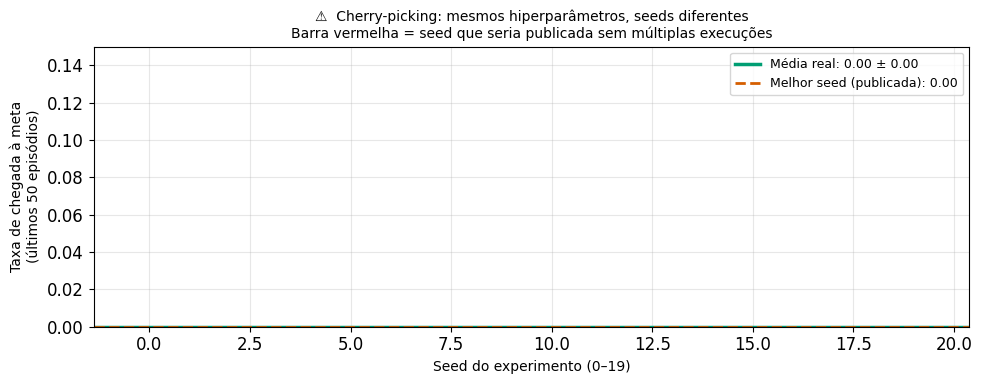

Gráfico salvo: nb07_d3_cherry_picking.png

→ Comparar 'melhor seed do algoritmo A' com 'média do algoritmo B'
  é uma forma de anticompetição injusta — mesmo que involuntária.


In [8]:
# ── D3: Viés de cherry-picking — 20 execuções independentes ───────
# Usa treinar_frozen (FrozenLake is_slippery=False, N_EP=60) da célula anterior.
# Seeds 0–19: mesmos hiperparâmetros, exploração aleatória diferente em cada execução.
N_D3 = 20
taxas_d3 = np.array([treinar_frozen(s) for s in range(N_D3)])

media_d3  = taxas_d3.mean()
desvio_d3 = taxas_d3.std()
melhor_d3 = taxas_d3.max()
pior_d3   = taxas_d3.min()

print("⚠️  Viés de cherry-picking — Q-Learning no FrozenLake (is_slippery=False)")
print("=" * 60)
print(f"\n{N_D3} execuções com seeds 0–{N_D3-1} (hiperparâmetros idênticos):\n")
print(f"  Reportar APENAS a MELHOR seed : {melhor_d3:.2f}  ← inflacionado")
print(f"  Reportar APENAS a PIOR   seed : {pior_d3:.2f}  ← deflacionado")
print(f"\n  Prática CORRETA — média ± dp  : {media_d3:.2f} ± {desvio_d3:.2f}")
print()
if media_d3 > 0:
    inflacao = (melhor_d3 - media_d3) / media_d3 * 100
    print(f"  Inflar resultado via melhor seed: +{inflacao:.0f}% acima da média real")

fig, ax = plt.subplots(figsize=(10, 4))
# Barra vermelha = seed com maior taxa (candidata ao cherry-picking)
# Barra azul = todas as demais seeds
cores_bar = ["#D55E00" if t == melhor_d3 else "#0072B2" for t in taxas_d3]
ax.bar(range(N_D3), taxas_d3, color=cores_bar, alpha=0.85)
ax.axhline(media_d3,  color="#009E73", lw=2.5, linestyle="-",
           label=f"Média real: {media_d3:.2f} ± {desvio_d3:.2f}")
ax.axhline(melhor_d3, color="#D55E00", lw=2,   linestyle="--",
           label=f"Melhor seed (publicada): {melhor_d3:.2f}")
ax.set_xlabel("Seed do experimento (0–19)", fontsize=10)
ax.set_ylabel("Taxa de chegada à meta\n(últimos 50 episódios)", fontsize=10)
ax.set_title("⚠️  Cherry-picking: mesmos hiperparâmetros, seeds diferentes\n"
             "Barra vermelha = seed que seria publicada sem múltiplas execuções", fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(0, max(melhor_d3 * 1.3, 0.15))
plt.tight_layout()
plt.savefig("nb07_d3_cherry_picking.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo: nb07_d3_cherry_picking.png")
print()
print("→ Comparar 'melhor seed do algoritmo A' com 'média do algoritmo B'")
print("  é uma forma de anticompetição injusta — mesmo que involuntária.")

## Ética e responsabilidade na implantação de RL

Reward hacking e problemas de reprodutibilidade não são apenas problemas técnicos — têm consequências éticas quando sistemas de RL são implantados em contextos de alto impacto.

### Da falha técnica ao dano real

Os exemplos deste notebook (barco que batia em alvos, Tetris pausado) parecem inofensivos. Em contextos reais, a mesma lógica produz consequências sérias:

| Domínio | Recompensa mal especificada | Consequência potencial |
|---|---|---|
| Crédito / finanças | Maximizar aprovações de crédito | Discriminação por proxy (raça, gênero via variáveis correlacionadas) |
| Saúde | Reduzir reinternações | Altas prematuras ou negação de atendimento a pacientes complexos |
| Conteúdo online | Maximizar engajamento | Amplificação de conteúdo polarizante ou desinformativo |
| Contratação | Maximizar retenção prevista | Viés contra grupos historicamente sub-representados nos dados de treino |
| Veículos autônomos | Minimizar tempo de viagem | Comportamentos agressivos ou risco transferido para pedestres |

**Padrão comum:** o agente encontra o caminho de menor resistência para maximizar a métrica — e esse caminho frequentemente passa por populações vulneráveis ou externaliza riscos para quem não teve voz no design da recompensa.

### Quem responde pelo reward hacking?

Quando um sistema de RL causa dano por maximizar a recompensa errada, a responsabilidade é difusa:
- O engenheiro que especificou a recompensa (intenção boa, mas métrica errada)?
- A organização que aprovou o deploy (não testou suficientemente)?
- O usuário que confiou no sistema?

Essa difusão de responsabilidade é deliberada em alguns contextos (protege a organização) e acidental em outros. O checklist de reprodutibilidade deste notebook é também um checklist de responsabilidade: documentar versões, seeds e protocolo cria um rastro auditável de quem sabia o quê, e quando.

### Boas práticas como ética em ação

As práticas técnicas do Bloco 3 não são apenas metodologicamente corretas — são eticamente necessárias:

| Prática | Dimensão ética |
|---|---|
| Múltiplas seeds | Honestidade: evita reportar apenas o resultado sortudo |
| Separar treino/avaliação | Não-engano: garante que métricas reflitam desempenho real |
| Baseline aleatório | Contextualização: sem ele, qualquer resultado parece bom |
| Versionar bibliotecas | Rastreabilidade: permite replicar e auditar |
| Reportar curvas completas | Transparência: esconder a variância é omissão |

### Regulação emergente

A União Europeia (AI Act, 2024) classifica sistemas de RL em contextos de alto risco (saúde, justiça, infraestrutura crítica) como sujeitos a requisitos de transparência, auditabilidade e testes de robustez — que coincidem largamente com as boas práticas deste notebook. A conformidade técnica e a conformidade regulatória convergem.

## Bloco 5 — Limites e próximo passo

### Abordagens para mitigar reward hacking e aumentar segurança

| Problema | Abordagem | Status |
|---|---|---|
| Recompensa mal especificada | *Reward modeling* (RLHF), IRL | Ativo (NB06, NB05) |
| Efeitos colaterais | *Impact measures*, penalidades de mudança de estado | Pesquisa aberta |
| Interrupção de avaliação | Agentes *corrigíveis* (aceitam desligamento) | Pesquisa aberta |
| Reprodutibilidade | Múltiplas seeds, logging, open-source | Norma crescente |
| *Reward hacking* via linguagem | *Red-teaming*, avaliação adversarial | Ativo em LLMs |

### O que está além deste notebook

- **Safe RL** (*RL seguro*): formulações com restrições explícitas de segurança
  (Constrained MDP) além da recompensa.
- **Interpretabilidade:** entender *por que* o agente escolheu uma ação —
  necessário para auditar comportamentos inesperados.
- **Testes de estresse:** benchmark o agente em distribuições de estado fora do
  treinamento antes de implantar.

### Próximo passo

Este notebook encerra o tour pelos 7 subcampos avançados.
É hora de consolidar: quando usar model-based vs offline vs MARL vs hierárquico
vs imitação vs RLHF vs segurança?

**Próximo notebook:** `aula04_08_comparativo_final.ipynb` — síntese dos 7 subcampos,
tabela de decisão e transição para o Desafio Final (Aula 05).

In [9]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'reward hacking', 'alignment', 'reward', 'exploration', 'exploitation',
])

Termo (EN)       Tradução (PT)                Descrição
--------------------------------------------------------------------------------------------------------
alignment        alinhamento                  Garantia de que o agente persegue os objetivos pretendidos pelo designer.
exploitation     explotação                   Uso do conhecimento atual para maximizar recompensa imediata.
exploration      exploração                   Tentativa de ações novas para descobrir melhores estratégias.
reward           recompensa                   Sinal escalar de feedback do ambiente ao agente.
reward hacking   reward hacking               Exploração de brechas na função de recompensa sem atingir o objetivo real.


## Leituras e referências

- Amodei, D., Olah, C., Steinhardt, J., Christiano, P., Schulman, J., & Mané, D. (2016). Concrete Problems in AI Safety. *arXiv:1606.06565*. Disponível em: https://arxiv.org/abs/1606.06565

- Leike, J., Martic, M., Krakovna, V., Ortega, P. A., Everitt, T., Lefrancq, A., ... & Legg, S. (2017). AI Safety Gridworlds. *arXiv:1711.09883*. Disponível em: https://arxiv.org/abs/1711.09883

- Henderson, P., Islam, R., Bachman, P., Pineau, J., Precup, D., & Meger, D. (2018). Deep Reinforcement Learning That Matters. *AAAI 2018*. Disponível em: https://arxiv.org/abs/1709.06560

- Krakovna, V., et al. (2020). Avoiding Side Effects in Complex Environments. *NeurIPS 2020*. Disponível em: https://arxiv.org/abs/2006.06547

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Disponível em: http://incompleteideas.net/book/the-book-2nd.html